In [3]:
# Importera bibliotek och sökväg till datafilen
import pandas as pd
import numpy as np
from pathlib import Path

# repo root = ligger en nivå upp från notebook
project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

file_path = project_folder / "data" / "XXH2023_YRBS_Data.dat"

print("Projektmapp:", project_folder)
print("Datafil:", file_path)
print("Finns filen?", file_path.exists())

Projektmapp: c:\Users\mahta\aidev\yrbs-sleep-social-media-analysis
Datafil: c:\Users\mahta\aidev\yrbs-sleep-social-media-analysis\data\XXH2023_YRBS_Data.dat
Finns filen? True


In [4]:
# Läser in de två variablerna från ASCII filen
df = pd.read_fwf(
    file_path,
    colspecs=[(111, 112), (116, 117)],
    header=None,
    names=["Q80", "Q85"],
    dtype=str
)

df.head()

,Q80,Q85
0,2,1
1,2,1
2,2,1
3,2,1
4,2,1


In [5]:
# Rensar data och översätter variablerna
df = df.replace(r"^\s*$", np.nan, regex=True)

df["Q80"] = pd.to_numeric(df["Q80"], errors="coerce")
df["Q85"] = pd.to_numeric(df["Q85"], errors="coerce")

social_media_map = {
    1: "I do not use social media",
    2: "A few times a month",
    3: "About once a week",
    4: "A few times a week",
    5: "About once a day",
    6: "Several times a day",
    7: "About once an hour",
    8: "More than once an hour"
}

sleep_map = {
    1: "4 or less hours",
    2: "5 hours",
    3: "6 hours",
    4: "7 hours",
    5: "8 hours",
    6: "9 hours",
    7: "10 or more hours"
}

df["social_media_label"] = df["Q80"].map(social_media_map)
df["sleep_label"] = df["Q85"].map(sleep_map)

df.head()

,Q80,Q85,social_media_label,sleep_label
0,2.0,1.0,A few times a month,4 or less hours
1,2.0,1.0,A few times a month,4 or less hours
2,2.0,1.0,A few times a month,4 or less hours
3,2.0,1.0,A few times a month,4 or less hours
4,2.0,1.0,A few times a month,4 or less hours


In [6]:
# Visar deskriptiv statistik och frekvenser
print("Frekvenser för sociala medier:")
print(df["social_media_label"].value_counts(dropna=False))

print("\nFrekvenser för sömn:")
print(df["sleep_label"].value_counts(dropna=False))

print("\nKodad sammanfattning:")
print(df[["Q80", "Q85"]].describe())

Frekvenser för sociala medier:
social_media_label
A few times a month          12101
About once a week             2346
NaN                           1374
I do not use social media     1072
Name: count, dtype: int64

Frekvenser för sömn:
sleep_label
4 or less hours     13851
NaN                  2352
5 hours               285
10 or more hours      192
6 hours                81
7 hours                51
9 hours                47
8 hours                34
Name: count, dtype: int64

Kodad sammanfattning:
                Q80           Q85
count  15519.000000  14541.000000
mean       2.082093      1.146001
std        0.462083      0.803579
min        1.000000      1.000000
25%        2.000000      1.000000
50%        2.000000      1.000000
75%        2.000000      1.000000
max        3.000000      7.000000


In [8]:
df["social_media_label"].value_counts()

social_media_label
A few times a month          12101
About once a week             2346
I do not use social media     1072
Name: count, dtype: int64

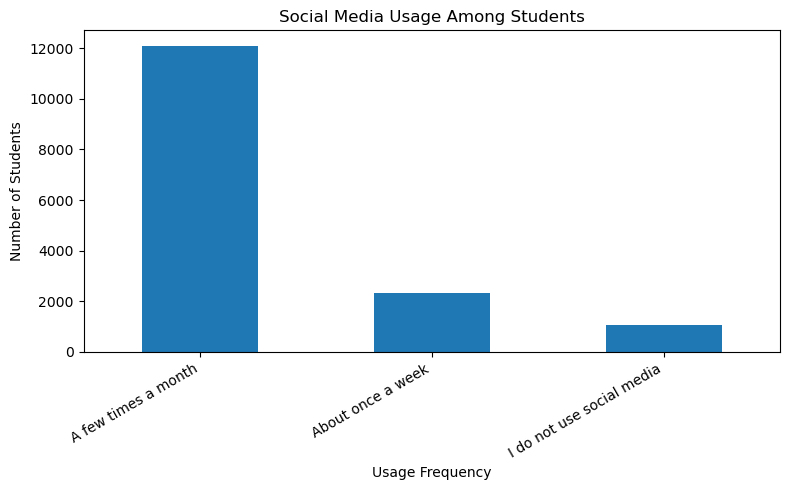

In [9]:
# Cellblock 6: Bar chart for social media

import matplotlib.pyplot as plt

social_counts = df["social_media_label"].value_counts()

plt.figure(figsize=(8, 5))
social_counts.plot(kind="bar")

plt.title("Social Media Usage Among Students")
plt.xlabel("Usage Frequency")
plt.ylabel("Number of Students")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("../results/figures/social_media_bar_chart_clean.png")

plt.show()

In [10]:
social_map = {
    "I do not use social media": 1,
    "A few times a month": 2,
    "About once a week": 3,
    "A few times a week": 4,
    "About once a day": 5,
    "Several times a day": 6,
    "About once an hour": 7,
    "More than once an hour": 8
}

sleep_map = {
    "4 or less hours": 4,
    "5 hours": 5,
    "6 hours": 6,
    "7 hours": 7,
    "8 hours": 8,
    "9 hours": 9,
    "10 or more hours": 10
}

df["social_numeric"] = df["social_media_label"].map(social_map)
df["sleep_numeric"] = df["sleep_label"].map(sleep_map)

In [11]:
print("Social Media:")
print("Mean:", df["social_numeric"].mean())
print("Median:", df["social_numeric"].median())
print("Mode:", df["social_numeric"].mode()[0])

print("\nSleep:")
print("Mean:", df["sleep_numeric"].mean())
print("Median:", df["sleep_numeric"].median())
print("Mode:", df["sleep_numeric"].mode()[0])

Social Media:
Mean: 2.082092918358142
Median: 2.0
Mode: 2.0

Sleep:
Mean: 4.146000962794856
Median: 4.0
Mode: 4.0


## Test 1: Correlation Analysis

We calculate the correlation between social media usage and sleep to explore if there is a relationship.

In [12]:
df[["social_numeric", "sleep_numeric"]].corr()

,social_numeric,sleep_numeric
social_numeric,1.000000,-0.022143
sleep_numeric,-0.022143,1.000000


In [13]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df["social_numeric"], df["sleep_numeric"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: nan
P-value: nan


In [14]:
df[["social_numeric", "sleep_numeric"]].isna().sum()

social_numeric    1374
sleep_numeric     2352
dtype: int64

In [15]:
social_map = {
    "I do not use social media": 1,
    "A few times a month": 2,
    "About once a week": 3
}

sleep_map = {
    "4 or less hours": 4,
    "5 hours": 5,
    "6 hours": 6,
    "7 hours": 7,
    "8 hours": 8
}

In [16]:
df["social_numeric"] = df["social_media_label"].map(social_map)
df["sleep_numeric"] = df["sleep_label"].map(sleep_map)

In [17]:
df[["social_numeric", "sleep_numeric"]].dropna().corr()

,social_numeric,sleep_numeric
social_numeric,1.000000,-0.034657
sleep_numeric,-0.034657,1.000000


In [18]:
from scipy.stats import spearmanr

clean_df = df.dropna(subset=["social_numeric", "sleep_numeric"])

corr, p_value = spearmanr(clean_df["social_numeric"], clean_df["sleep_numeric"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.04172907790680831
P-value: 2.0330043335050788e-06


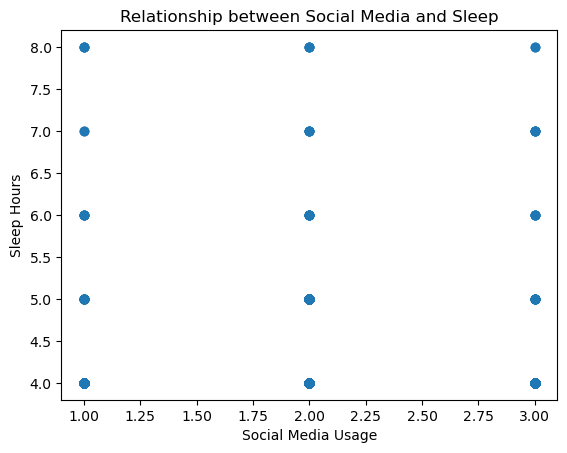

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df["social_numeric"], df["sleep_numeric"], alpha=0.5)
plt.xlabel("Social Media Usage")
plt.ylabel("Sleep Hours")
plt.title("Relationship between Social Media and Sleep")
plt.show()